In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

seed = 1234
np.random.seed(seed)

pd.set_option('display.max_columns', None)

## Add Split Logic
---
## Preprocessing Should Happen for both training and test datasets

In [2]:
df = pd.read_csv('training_data.csv')
df.head()

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,1,MC,?,34,0,10,6,0,0,490,427,571,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,2,?,Family/GeneralPractice,39,0,11,0,0,0,428,250,305,4,NaN,NaN,Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,5,?,Family/GeneralPractice,63,1,11,1,0,11,535,285,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,2,MC,?,39,0,22,3,0,2,482,428,585,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,12,?,InternalMedicine,71,1,15,0,0,0,733,584,682,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30


In [3]:
df.isnull().sum()

Unnamed: 0                      0
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               86780
A1Cresult                   76267
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [4]:
"""
Imputing with NaN to get True NaN missing value counts

"""
missing_cols = ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'gender']

column_to_missing = {}
for col in missing_cols:
    if col != 'gender':
        column_to_missing[col] = '?'
    else:
        column_to_missing[col] = 'Unknown/Invalid'

print(column_to_missing)

{'race': '?', 'weight': '?', 'payer_code': '?', 'medical_specialty': '?', 'diag_1': '?', 'diag_2': '?', 'diag_3': '?', 'gender': 'Unknown/Invalid'}


In [5]:
df_1 = df.copy()
for col, miss_val in column_to_missing.items():
    df_1[col] = df_1[col].replace(miss_val, np.nan)
message = "True Missing Counts:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().sum()

True Missing Counts:


Unnamed: 0                      0
encounter_id                    0
patient_nbr                     0
race                         2044
gender                          2
age                             0
weight                      88727
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  36237
medical_specialty           44911
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         19
diag_2                        332
diag_3                       1292
number_diagnoses                0
max_glu_serum               86780
A1Cresult                   76267
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [6]:
message = "Percentage of Missing Values:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().mean().round(4)*100

Percentage of Missing Values:


Unnamed: 0                   0.00
encounter_id                 0.00
patient_nbr                  0.00
race                         2.23
gender                       0.00
age                          0.00
weight                      96.88
admission_type_id            0.00
discharge_disposition_id     0.00
admission_source_id          0.00
time_in_hospital             0.00
payer_code                  39.56
medical_specialty           49.04
num_lab_procedures           0.00
num_procedures               0.00
num_medications              0.00
number_outpatient            0.00
number_emergency             0.00
number_inpatient             0.00
diag_1                       0.02
diag_2                       0.36
diag_3                       1.41
number_diagnoses             0.00
max_glu_serum               94.75
A1Cresult                   83.27
metformin                    0.00
repaglinide                  0.00
nateglinide                  0.00
chlorpropamide               0.00
glimepiride   

In [7]:
df_1_non_numeric = df_1.select_dtypes(exclude='number')
for col in df_1_non_numeric.columns.values:
    print(f"{col}: ", df_1[col].unique(), end='\n\n')

race:  ['Caucasian' 'AfricanAmerican' 'Hispanic' nan 'Other' 'Asian']

gender:  ['Female' 'Male' nan]

age:  ['[60-70)' '[40-50)' '[70-80)' '[80-90)' '[50-60)' '[30-40)' '[20-30)'
 '[90-100)' '[10-20)' '[0-10)']

weight:  [nan '[75-100)' '[100-125)' '[50-75)' '[125-150)' '[25-50)' '[0-25)'
 '[150-175)' '[175-200)' '>200']

payer_code:  ['MC' nan 'BC' 'CM' 'SP' 'HM' 'OG' 'MD' 'UN' 'CP' 'OT' 'PO' 'DM' 'WC' 'SI'
 'CH' 'MP' 'FR']

medical_specialty:  [nan 'Family/GeneralPractice' 'InternalMedicine' 'Cardiology'
 'Surgery-General' 'Surgery-Vascular' 'Urology' 'Emergency/Trauma'
 'Surgery-Neuro' 'Orthopedics-Reconstructive'
 'PhysicalMedicineandRehabilitation' 'Surgery-Cardiovascular/Thoracic'
 'ObstetricsandGynecology' 'Gastroenterology' 'Orthopedics'
 'Surgery-Plastic' 'Podiatry' 'Surgery-Thoracic' 'Nephrology' 'Psychiatry'
 'Radiologist' 'Pulmonology' 'Pediatrics-CriticalCare' 'Psychology'
 'Pediatrics-Endocrinology' 'Neurology' 'Hematology/Oncology' 'Pediatrics'
 'OutreachServices' 'Surg

In [8]:
"""
Diagnosis Groups:

Grouping based on ICD9 Grouping (source: Wikipedia)
"""
diags_ICD9_dict = {
    '001–139': 'infectious and parasitic diseases',
    '140–239': 'neoplasms',
    '240–279': 'endocrine, nutritional and metabolic diseases, and immunity disorders',
    '280–289': 'diseases of the blood and blood-forming organs',
    '290–319': 'mental disorders',
    '320–389': 'diseases of the nervous system and sense organs',
    '390–459': 'diseases of the circulatory system',
    '460–519': 'diseases of the respiratory system',
    '520–579': 'diseases of the digestive system',
    '580–629': 'diseases of the genitourinary system',
    '630–679': 'complications of pregnancy, childbirth, and the puerperium',
    '680–709': 'diseases of the skin and subcutaneous tissue',
    '710–739': 'diseases of the musculoskeletal system and connective tissue',
    '740–759': 'congenital anomalies',
    '760–779': 'certain conditions originating in the perinatal period',
    '780–799': 'symptoms, signs, and ill-defined conditions',
    '800–999': 'injury and poisoning',
    'E & V codes': 'external causes of injury and supplemental classification',
}

def categorize_diag(code: str) -> str:
    code_float = float(code)
    code_int = int(code_float)
    if code_int >= 800:
        return '800–999'
    elif code_int >= 780:
        return '780–799'
    elif code_int >= 760:
        return '760–779'
    elif code_int >= 740:
        return '740–759'
    elif code_int >= 710:
        return '710–739'
    elif code_int >= 680:
        return '680–709'
    elif code_int >= 630:
        return '630–679'
    elif code_int >= 580:
        return '580–629'
    elif code_int >= 520:
        return '520–579'
    elif code_int >= 460:
        return '460–519'
    elif code_int >= 390:
        return '390–459'
    elif code_int >= 320:
        return '320–389'
    elif code_int >= 290:
        return '290–319'
    elif code_int >= 280:
        return '280–289'
    elif code_int >= 240:
        return '240–279'
    elif code_int >= 140:
        return '140–239'
    else:
        return '001–139'

def convert_EV_code(code: str) -> str:
    return 'E & V codes'


"""
Medical Specialty Groups:

Grouping based on Google Gemini output
"""

specialty_mapping = {
    'PrimaryCare': [
        'Family/GeneralPractice', 'InternalMedicine', 'Hospitalist', 
        'Osteopath', 'Resident'
    ],
    'Surgery': [
        'Surgery-General', 'Surgery-Vascular', 'Urology', 'Surgery-Neuro', 
        'Orthopedics-Reconstructive', 'Surgery-Cardiovascular/Thoracic', 
        'Orthopedics', 'Surgery-Plastic', 'Podiatry', 'Surgery-Thoracic', 
        'Surgery-Colon&Rectal', 'Otolaryngology', 'Surgery-Cardiovascular', 
        'Surgeon', 'Proctology', 'Surgery-Maxillofacial', 'SurgicalSpecialty', 
        'Dentistry', 'Ophthalmology', 'Surgery-PlasticwithinHeadandNeck'
    ],
    'InternalMedicine_Subspecialty': [
        'Cardiology', 'Gastroenterology', 'Nephrology', 'Pulmonology', 
        'Neurology', 'Hematology/Oncology', 'Endocrinology-Metabolism', 
        'Hematology', 'Oncology', 'Endocrinology', 'InfectiousDiseases', 
        'Rheumatology', 'AllergyandImmunology', 'Neurophysiology', 'Dermatology'
    ],
    'Emergency_CriticalCare': [
        'Emergency/Trauma'
    ],
    'Maternal_Pediatric': [
        'ObstetricsandGynecology', 'Pediatrics-CriticalCare', 'Pediatrics-Endocrinology', 
        'Pediatrics', 'Gynecology', 'Pediatrics-Pulmonology', 'Pediatrics-Neurology', 
        'Obsterics&Gynecology-GynecologicOnco', 'Pediatrics-AllergyandImmunology', 
        'Cardiology-Pediatric', 'Anesthesiology-Pediatric', 'Obstetrics', 
        'Surgery-Pediatric', 'Perinatology', 'Pediatrics-EmergencyMedicine', 
        'Pediatrics-Hematology-Oncology', 'Psychiatry-Child/Adolescent', 
        'Pediatrics-InfectiousDiseases'
    ],
    'Psych_Rehab_Support': [
        'PhysicalMedicineandRehabilitation', 'Psychiatry', 'Psychology', 
        'Anesthesiology', 'Speech', 'SportsMedicine'
    ],
    'Diagnostics_Other': [
        'Radiologist', 'Radiology', 'Pathology', 'OutreachServices', 'DCPTEAM'
    ],
    'Missing': [
        'PhysicianNotFound'
    ]
}

def map_specialty_to_group(specialty):
    if pd.isna(specialty):
        return specialty
    for key, value in specialty_mapping.items():
        if specialty in value:
            return key
    return 'Other'

def build_map_to_none(categories : list[int]):
    def map_to_one(category):
        if category in categories:
            return np.nan
        return category
    return map_to_one

---
## Starting Feature Transformations & Imputation

In [9]:
"""
Grouping Transformations (4 total)

2 types: diagnosis and medical specialty
"""

"""
Categorizing diagnoses codes into diagnosis groups => reduces features.

Applies to: `diag_1`, `diag_2`, & `diag_3`
"""
df_2 = df_1.copy()
for i in range(1,4):

    mask = df_2[f'diag_{i}'].str.contains('^[EV]', regex=True, na=False)
    mask_nan = df_2[f'diag_{i}'].isna()
    combined_mask = mask | mask_nan
    
    df_2.loc[~combined_mask, f'diag_{i}'] = df_2.loc[~combined_mask, f'diag_{i}'].apply(categorize_diag)
    df_2.loc[mask, f'diag_{i}'] = df_2.loc[mask, f'diag_{i}'].apply(convert_EV_code)
    print(f"diag_{i}: ", df_2[f'diag_{i}'].unique(), end='\n\n')

"""
Based on medical specialty => reduces total features

Applies to: `medical_specialty`
"""
df_2['medical_specialty'] = df_2['medical_specialty'].apply(map_specialty_to_group)
print("medical_specialty: ", df_2['medical_specialty'].unique(), end = "\n\n")

"""
Categorizing ambiguous mappings together.

For example, admission_source_id has categories 9, 15, 17, 20, and 21, which map to
Not availble, not availible, Null, not mapped, unknown

Group 9, 15, 17, 20 and 21 together to null. Reduces features & remove noise

Applies to `admission_type_id`, `discharge_disposition_id`, `admission_source_id`
"""
df_2['admission_type_id'] = df_2['admission_type_id'].apply(build_map_to_none([5, 6, 8]))
df_2['discharge_disposition_id'] = df_2['discharge_disposition_id'].apply(build_map_to_none([18, 25, 26]))
df_2['admission_source_id'] = df_2['admission_source_id'].apply(build_map_to_none([9, 15, 17, 20, 21]))

print("admission_type_id: ", np.sort(df_2['admission_type_id'].unique()), end = "\n\n")
print("discharge_disposition_id: ", np.sort(df_2['discharge_disposition_id'].unique()), end = "\n\n")
print("admission_source_id: ", np.sort(df_2['admission_source_id'].unique()), end = "\n\n")

diag_1:  ['460–519' '390–459' '520–579' '710–739' '800–999' '780–799' '290–319'
 '140–239' '240–279' '580–629' '001–139' 'E & V codes' '630–679' '680–709'
 '280–289' '320–389' nan '740–759']

diag_2:  ['390–459' '240–279' '280–289' '580–629' 'E & V codes' '780–799' '460–519'
 '320–389' '520–579' '290–319' '680–709' '001–139' '800–999' '710–739'
 '140–239' '630–679' nan '740–759']

diag_3:  ['520–579' '290–319' '580–629' '680–709' '390–459' '240–279' 'E & V codes'
 '001–139' '460–519' '320–389' '280–289' '780–799' '630–679' '800–999'
 '710–739' nan '740–759' '140–239']

medical_specialty:  [nan 'PrimaryCare' 'InternalMedicine_Subspecialty' 'Surgery'
 'Emergency_CriticalCare' 'Psych_Rehab_Support' 'Maternal_Pediatric'
 'Diagnostics_Other' 'Missing']

admission_type_id:  [ 1.  2.  3.  4.  7. nan]

discharge_disposition_id:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 19.
 20. 22. 23. 24. 27. 28. nan]

admission_source_id:  [ 1.  2.  3.  4.  5.  6.  7.  8. 10. 11. 

In [10]:
"""
Feature Drops:

Reasoning: 
- feature has missing 90+% of values (weight)
- feature only consists of 1 unique value
"""
df_3 = df_2.copy()
df_3.drop(columns=['weight', 'examide', 'citoglipton'], inplace=True)
print("Shape BEFORE drops: ", df_2.shape)
print("Shape AFTER drops: ", df_3.shape)

Shape BEFORE drops:  (91589, 51)
Shape AFTER drops:  (91589, 48)


In [11]:
"""
Mode Imputation
"""
df_4 = df_3.copy()
mode_impute_col_names = ['race', 'payer_code', 'medical_specialty', 'gender', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

def mode_impute(df_column):
    mask = df_column.notna()
    mode = df_column[mask].mode()[0]
    print(f"Mode:\t\t", mode)
    updated_df_column = df_column.fillna(mode)
    return updated_df_column

for name in mode_impute_col_names:
    print(name, end=' ')
    df_4[name] = mode_impute(df_4[name])

race Mode:		 Caucasian
payer_code Mode:		 MC
medical_specialty Mode:		 PrimaryCare
gender Mode:		 Female
diag_1 Mode:		 390–459
diag_2 Mode:		 390–459
diag_3 Mode:		 390–459
admission_type_id Mode:		 1.0
discharge_disposition_id Mode:		 1.0
admission_source_id Mode:		 7.0


In [12]:
message = "Before Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_3[mode_impute_col_names].isnull().sum()

Before Mode Impute:


race                         2044
payer_code                  36237
medical_specialty           44911
gender                          2
diag_1                         19
diag_2                        332
diag_3                       1292
admission_type_id            9319
discharge_disposition_id     4207
admission_source_id          6358
dtype: int64

In [13]:
message = "After Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_4[mode_impute_col_names].isnull().sum()

After Mode Impute:


race                        0
payer_code                  0
medical_specialty           0
gender                      0
diag_1                      0
diag_2                      0
diag_3                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
dtype: int64

In [14]:
"""
NaN Replacement:

Treating Unknown as a possible valid value.

Applies to: 'max_glu_serum', 'A1Cresult'

Based on potential significance of these values missing.
"""
df_5 = df_4.copy()
col_names = ['max_glu_serum', 'A1Cresult']

for name in col_names:
    df_5[name] = df_5[name].replace(np.nan, 'Unknown')

In [15]:
message = "After ALL Transformations and Imputes:"
print(message, '\n', '='*len(message), sep='')
df_5.isna().sum()

After ALL Transformations and Imputes:


Unnamed: 0                  0
encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

## Done with Imputations and Transformations
---
## Starting Encoding
### **NOTE**: Use `df_5` from this point onwards.

In [16]:
# df_5_non_numeric = df_5.select_dtypes(exclude='number')

# categorical_columns = list(df_5_non_numeric.columns.values)
# categorical_columns += ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

# non_ordinal_cols = [categorical_columns[0]] + categorical_columns[3:8] + categorical_columns[33:]
# ordinal_cols = categorical_columns[1:3] + categorical_columns[8:33]

# print("categorical_columns: ", categorical_columns, end='\n\n')
# print("Non Ordinal: ", non_ordinal_cols, end='\n\n')
# print("Ordinal: ", ordinal_cols)

df_5_non_numeric = df_5.select_dtypes(exclude='number')

categorical_columns = list(df_5_non_numeric.columns.values)
categorical_columns += ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

non_ordinal_cols = [categorical_columns[0]] + categorical_columns[3:8] + categorical_columns[34:]
ordinal_cols = categorical_columns[1:3] + categorical_columns[8:34]

print("categorical_columns: ", categorical_columns, end='\n\n')
print("Non Ordinal: ", non_ordinal_cols, end='\n\n')
print("Ordinal: ", ordinal_cols)

categorical_columns:  ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Non Ordinal:  ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Ordinal:  ['gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 

In [17]:
"""
Define Orderings for every ordinal column
"""

quad_med = ['Down', 'No', 'Steady', 'Up']
binary_med = ['No', 'Steady']

mapping = {
    # Custom/Unique orderings
    'gender': ['Male', 'Female'],
    'age': ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'],
    'weight': ['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)', '[125-150)', '[150-175)', '[175-200)', '>200'],
    'max_glu_serum': ['Unknown', 'Norm', '>200', '>300'],
    'A1Cresult': ['Unknown', 'Norm', '>7', '>8'],
    'change': ['No', 'Ch'],
    'diabetesMed': ['No', 'Yes'],
    'readmitted': ['NO', '>30', '<30'],
    
    # 3-level medication (Unique)
    'tolazamide': ['No', 'Steady', 'Up'],
    
    # 4-level medications (Repeated)
    'metformin': quad_med,
    'repaglinide': quad_med,
    'nateglinide': quad_med,
    'chlorpropamide': quad_med,
    'glimepiride': quad_med,
    'glipizide': quad_med,
    'glyburide': quad_med,
    'pioglitazone': quad_med,
    'rosiglitazone': quad_med,
    'acarbose': quad_med,
    'miglitol': quad_med,
    'insulin': quad_med,
    'glyburide-metformin': quad_med,
    
    # 2-level medications (Repeated)
    'acetohexamide': binary_med,
    'tolbutamide': binary_med,
    'troglitazone': binary_med,
    'glipizide-metformin': binary_med,
    'glimepiride-pioglitazone': binary_med,
    'metformin-rosiglitazone': binary_med,
    'metformin-pioglitazone': binary_med
}

In [18]:
"""
Performing Encodings:

First starting with Ordinal Encoding

Second doing the Non-ordinal (OneHot) Encoding
"""

df_6 = df_5.copy()

# Ordinal Encoding
for col in ordinal_cols:
    ord_enc = OrdinalEncoder(categories=[mapping[col]])
    df_6[col] = ord_enc.fit_transform(df_6[[col]])

# Non-Ordinal, One-Hot Encoding
df_6 = pd.get_dummies(df_6, columns=non_ordinal_cols, drop_first=True)

In [19]:
df_6.head()

,Unnamed: 0,encounter_id,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency_CriticalCare,medical_specialty_InternalMedicine_Subspecialty,medical_specialty_Maternal_Pediatric,medical_specialty_Missing,medical_specialty_PrimaryCare,medical_specialty_Psych_Rehab_Support,medical_specialty_Surgery,diag_1_140–239,diag_1_240–279,diag_1_280–289,diag_1_290–319,diag_1_320–389,diag_1_390–459,diag_1_460–519,diag_1_520–579,diag_1_580–629,diag_1_630–679,diag_1_680–709,diag_1_710–739,diag_1_740–759,diag_1_780–799,diag_1_800–999,diag_1_E & V codes,diag_2_140–239,diag_2_240–279,diag_2_280–289,diag_2_290–319,diag_2_320–389,diag_2_390–459,diag_2_460–519,diag_2_520–579,diag_2_580–629,diag_2_630–679,diag_2_680–709,diag_2_710–739,diag_2_740–759,diag_2_780–799,diag_2_800–999,diag_2_E & V codes,diag_3_140–239,diag_3_240–279,diag_3_280–289,diag_3_290–319,diag_3_320–389,diag_3_390–459,diag_3_460–519,diag_3_520–579,diag_3_580–629,diag_3_630–679,diag_3_680–709,diag_3_710–739,diag_3_740–759,diag_3_780–799,diag_3_800–999,diag_3_E & V codes,admission_type_id_2.0,admission_type_id_3.0,admission_type_id_4.0,admission_type_id_7.0,discharge_disposition_id_2.0,discharge_disposition_id_3.0,discharge_disposition_id_4.0,discharge_disposition_id_5.0,discharge_disposition_id_6.0,discharge_disposition_id_7.0,discharge_disposition_id_8.0,discharge_disposition_id_9.0,discharge_disposition_id_10.0,discharge_disposition_id_11.0,discharge_disposition_id_12.0,discharge_disposition_id_13.0,discharge_disposition_id_14.0,discharge_disposition_id_15.0,discharge_disposition_id_16.0,discharge_disposition_id_17.0,discharge_disposition_id_19.0,discharge_disposition_id_20.0,discharge_disposition_id_22.0,discharge_disposition_id_23.0,discharge_disposition_id_24.0,discharge_disposition_id_27.0,discharge_disposition_id_28.0,admission_source_id_2.0,admission_source_id_3.0,admission_source_id_4.0,admission_source_id_5.0,admission_source_id_6.0,admission_source_id_7.0,admission_source_id_8.0,admission_source_id_10.0,admission_source_id_11.0,admission_source_id_13.0,admission_source_id_14.0,admission_source_id_22.0,admission_source_id_25.0
0,83148,259912530,88114716,1.0,6.0,1,34,0,10,6,0,0,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,8067,37094196,604017,1.0,6.0,2,39,0,11,0,0,0,4,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,Fal

## End of Encodings
---
### **NOTE**: Please use `df_6` from here on out.
---
## Start of EDA - Exploratory Data Analysis

<Axes: >

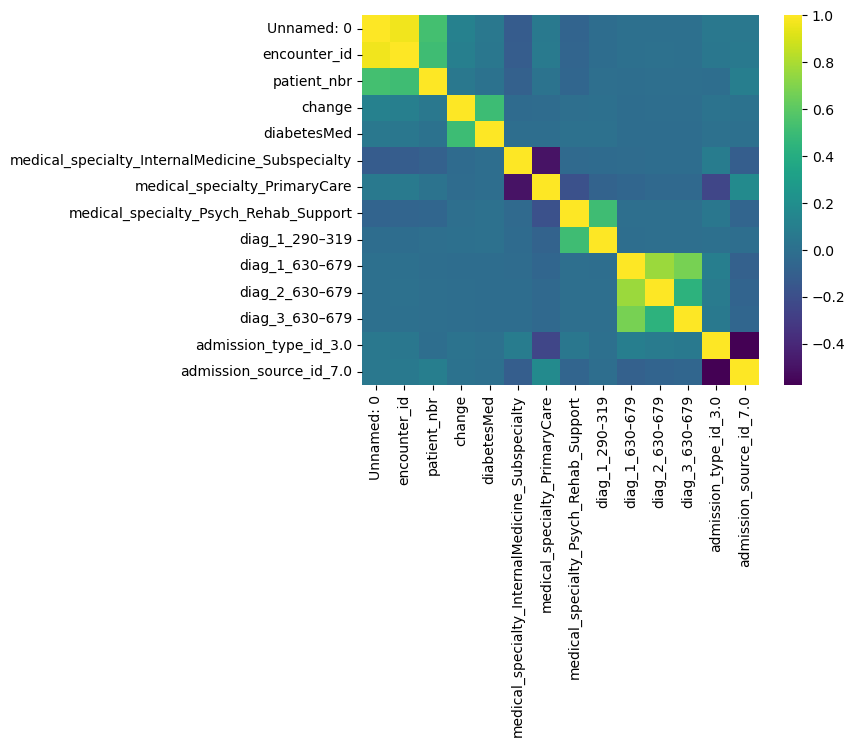

In [20]:
min_thresh = 0.5
corr_matrix = df_6.corr(numeric_only=True)
high_corr_features = corr_matrix.index[(abs(corr_matrix) >= min_thresh).sum() > 1]
high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
sns.heatmap(high_corr_matrix, cmap='viridis')

In [21]:
"""
Skew Analysis
"""
# Skewness Thresholds
upper_bound, lower_bound = 0.5, -0.5

all_cols = df_6.columns
encoded_cols = set(df_6.filter(regex=rf"^({'|'.join(categorical_columns)})_").columns)
non_encoded_cols = [c for c in all_cols if c not in encoded_cols]

non_encoded_skews = []
for col in sorted(non_encoded_cols):
    if pd.api.types.is_numeric_dtype(df_6[col]):
        skewness = df_6[col].skew()
        if skewness > upper_bound or skewness < lower_bound:
            non_encoded_skews.append((col,skewness))

encoded_skews = []
for category in categorical_columns:
    cols = df_6.filter(regex=rf'^{category}_').columns
    if not cols.empty:
        series = df_6[cols].values.argmax(axis=1)
        group_skew = pd.Series(series).skew()
        if group_skew > upper_bound or group_skew < lower_bound:
            encoded_skews.append((category, group_skew))

non_encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))
encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))

message = "Skewed Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in non_encoded_skews:
    print(f"{col:30} Skew: {skew:.4f}")

message = "\nSkewed Non-Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in encoded_skews:
    print(f"Grouped {col:22} Skew: {skew:.4f}")

Skewed Ordinal Columns:
acetohexamide                  Skew: 302.6367
glimepiride-pioglitazone       Skew: 302.6367
metformin-pioglitazone         Skew: 302.6367
metformin-rosiglitazone        Skew: 302.6367
troglitazone                   Skew: 302.6367
glipizide-metformin            Skew: 95.6880
tolbutamide                    Skew: 67.6506
tolazamide                     Skew: 54.2353
miglitol                       Skew: 46.6691
chlorpropamide                 Skew: 36.8230
number_emergency               Skew: 23.8095
acarbose                       Skew: 18.6509
nateglinide                    Skew: 12.4290
glyburide-metformin            Skew: 12.0035
number_outpatient              Skew: 8.9312
repaglinide                    Skew: 8.4440
max_glu_serum                  Skew: 5.2494
glimepiride                    Skew: 4.3353
rosiglitazone                  Skew: 3.7772
number_inpatient               Skew: 3.6163
pioglitazone                   Skew: 3.4828
glyburide                      Sk

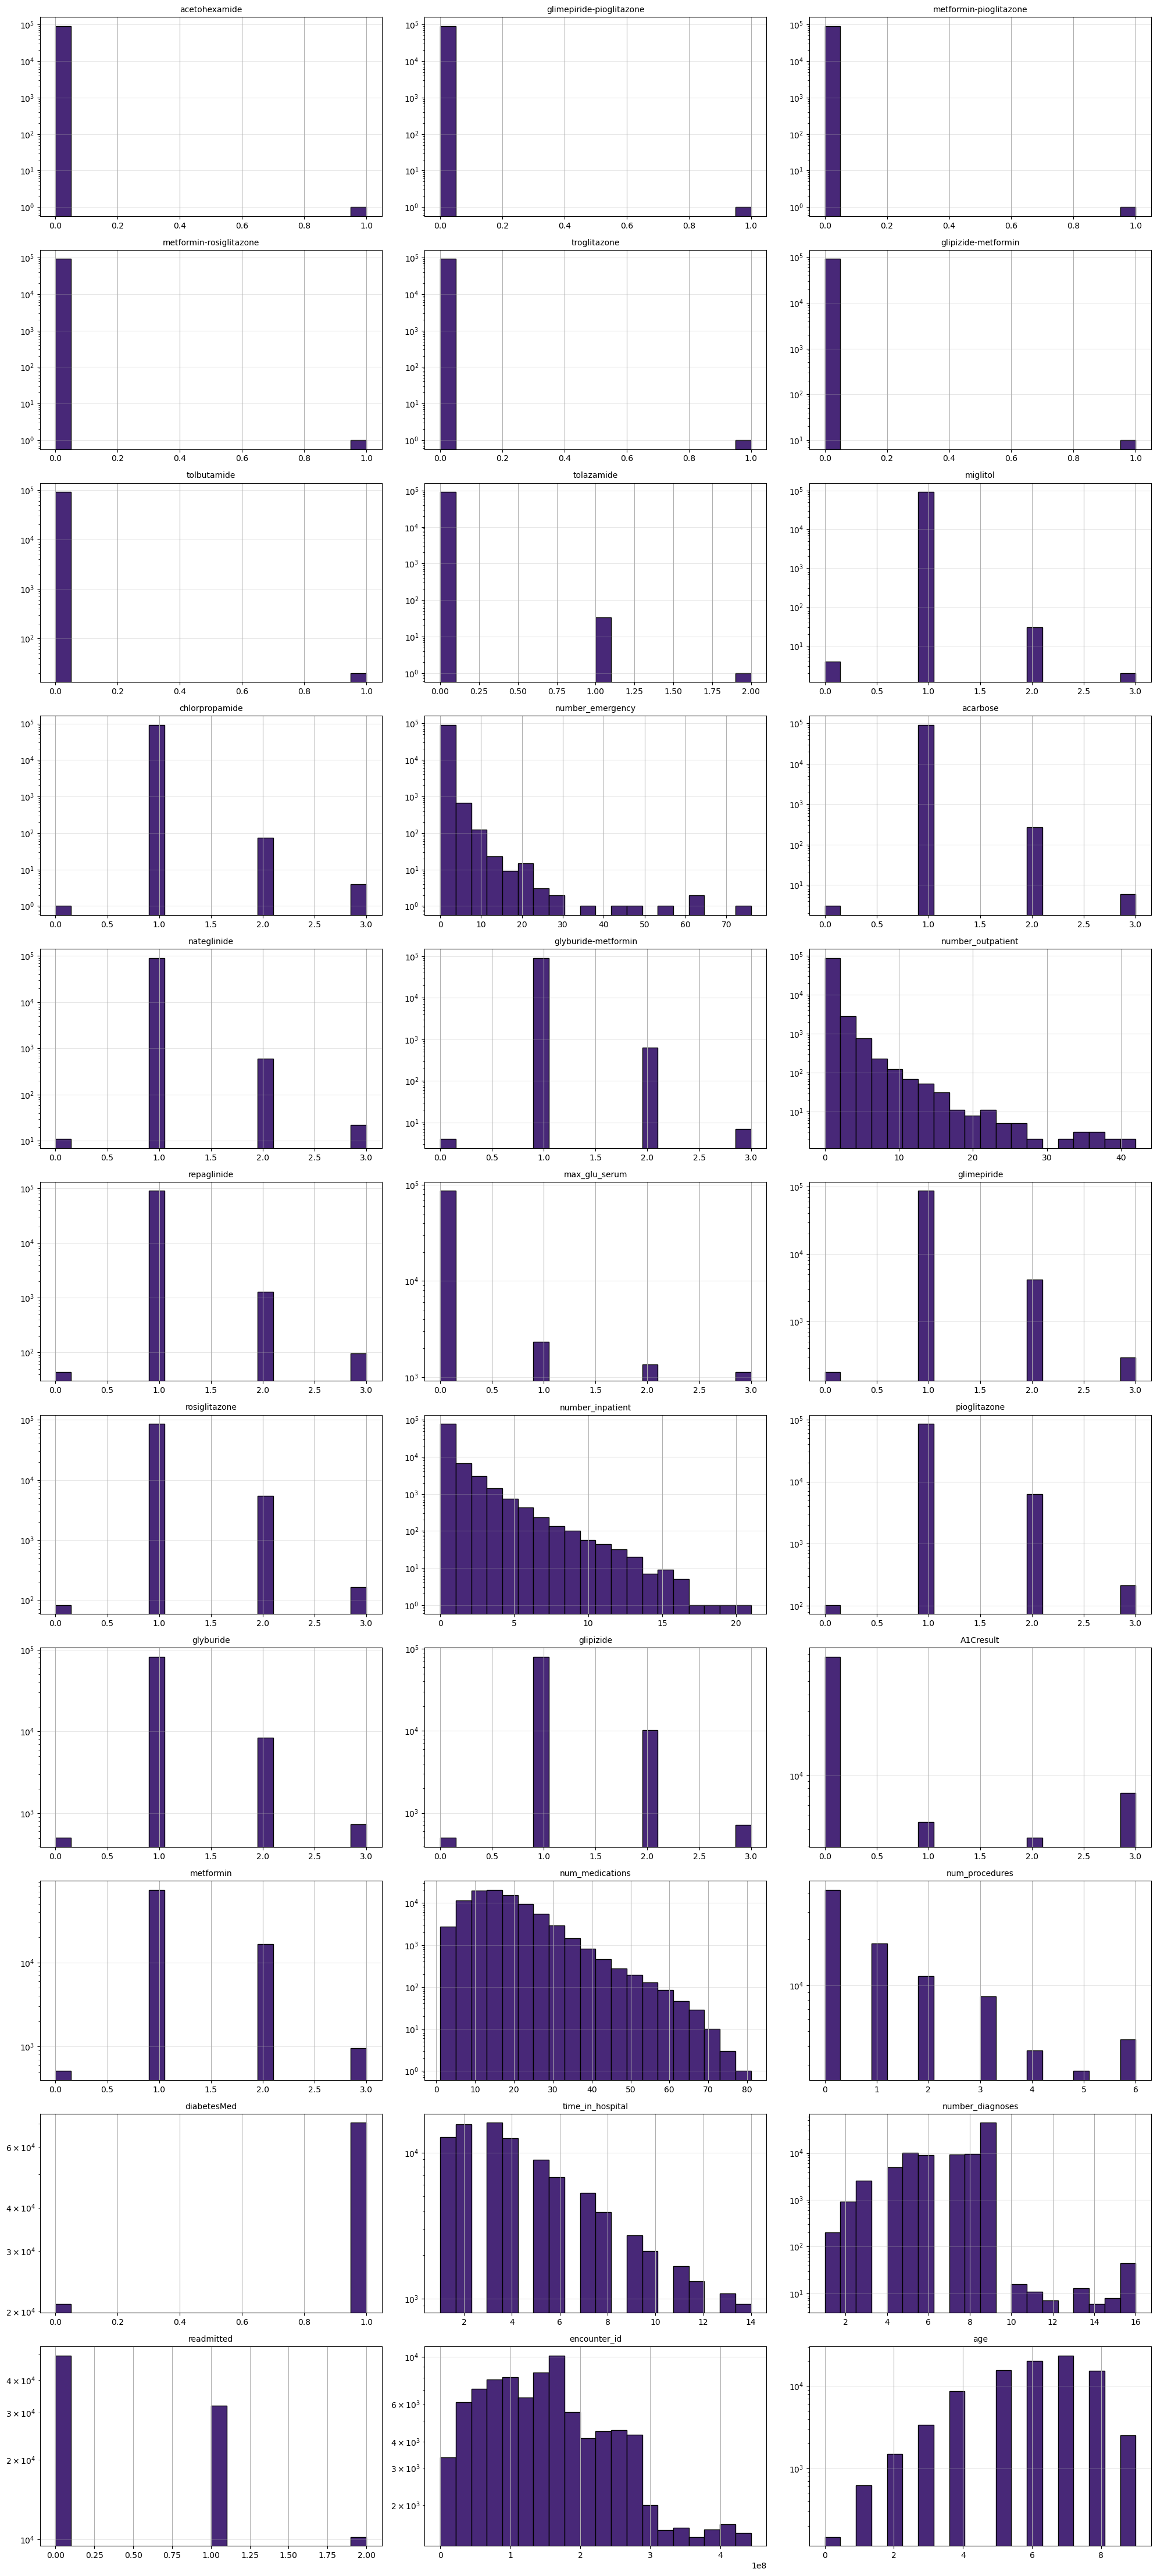

In [22]:
"""
Visualize Skew in Data via Histogram
"""
num_features = len(non_encoded_skews)
num_cols = 3
num_rows = num_features // num_cols + 1

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
axes = axes.flatten()

for i, (col, skew) in enumerate(non_encoded_skews):
    ax = axes[i]
    
    df_6[col].hist(ax=ax, color='#482878', edgecolor='black', bins=20)
    
    ax.set_yscale('log')
    
    ax.set_title(f"{col}", fontsize=10)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Our data has way too many features (155), our KNN model will suffer from the curse of dimensionality and will not give us an accurate model.     
2. We want to aim to around ~50 features      
3. We can combat this by feature selection, to reduce high-dimensional data into a lower-dimensional space before doing our KNN algorithms


In [23]:
"""
Log Transforms => Logistic Classifer
"""

'\nLog Transforms => Logistic Classifer\n'

In [24]:
"""
Multicollinearity Test
"""

'\nMulticollinearity Test\n'

## End of Exploratory Data Analysis
---
## Start of Model Building

## K-Nearest Neighbors

### Ideas before approaching this problem

### Pre Processing Step:
1. Our data has way too many features (154), our KNN model will suffer from the curse of dimensionality and will not give us an accurate model.   
1.a. We want to aim to around ~50 features
1.b. We can combat this by feature selection, to reduce high-dimensional data into a lower-dimensional space before doing our KNN algorithms

### Overall pipe-line:
1. Split data
2. ~~Drop near-constant features (noise reduction)~~ Ignore this for now
3. Log transform numeric features
4. Scaling
5. Dimension Reduction and Train KNN
6. Finalize with tuning hyperparameters and evaluate
7. Summary and Conclusion

# `1. Split Data`

In [25]:
"""
Splitting Data
"""
X = df_6.drop(columns=["readmitted"])
y = df_6["readmitted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.9, test_size=.1, shuffle=True, random_state=seed)
X_train.shape

(82430, 153)

# NOTE: `2. Drop Near-Constant Features`
# We are not doing this just to test, since dropping near-constant features made our model worse

In [26]:
"""
Dropping near-constant features
"""

# We want to check for a variance threshold, see if some features only have 99% of the same data
cols_to_drop = [col for col in X_train.columns 
                if X_train[col].value_counts(normalize=True).max() > 0.99]

message = f"\n{len(cols_to_drop)} columns that are catergorically near-constant >99%:"
print(message, '\n', "="*len(message), sep='')

cols_to_drop



57 columns that are catergorically near-constant >99%:


['nateglinide',
 'chlorpropamide',
 'acetohexamide',
 'tolbutamide',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'race_Asian',
 'payer_code_CH',
 'payer_code_DM',
 'payer_code_FR',
 'payer_code_MP',
 'payer_code_OT',
 'payer_code_PO',
 'payer_code_SI',
 'payer_code_WC',
 'medical_specialty_Missing',
 'diag_1_630–679',
 'diag_1_740–759',
 'diag_2_630–679',
 'diag_2_740–759',
 'diag_3_630–679',
 'diag_3_740–759',
 'admission_type_id_4.0',
 'admission_type_id_7.0',
 'discharge_disposition_id_4.0',
 'discharge_disposition_id_7.0',
 'discharge_disposition_id_8.0',
 'discharge_disposition_id_9.0',
 'discharge_disposition_id_10.0',
 'discharge_disposition_id_12.0',
 'discharge_disposition_id_13.0',
 'discharge_disposition_id_14.0',
 'discharge_disposition_id_15.0',
 'discharge_disposition_id_16.0',
 'discharge_disposition_id_17.0',
 'discharge_disp

# `3. Log Transform`

In [27]:
"""
Log-transform numeric features
"""

# Separate numeric/binary/low cardinal features

# Numeric cols
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Binary cols
binary_cols = [
    col for col in numeric_cols
    if X_train[col].nunique() == 2
]

# Low cardinality cols
min_cardinality = 10
low_card_cols = [
    col for col in numeric_cols
    if X_train[col].nunique() <= min_cardinality
]

# Now we select the log-canditates, seperate binary and low card from the numeric cols
log_candidates = list(
    set(numeric_cols) - set(binary_cols) - set(low_card_cols)
)

print(len(log_candidates))
log_candidates

10


['encounter_id',
 'number_emergency',
 'num_medications',
 'number_outpatient',
 'Unnamed: 0',
 'num_lab_procedures',
 'number_diagnoses',
 'number_inpatient',
 'patient_nbr',
 'time_in_hospital']

In [28]:
X_train[log_candidates].skew()

encounter_id           0.703106
number_emergency      21.026283
num_medications        1.318178
number_outpatient      8.883190
Unnamed: 0             0.005475
num_lab_procedures    -0.240612
number_diagnoses      -0.873608
number_inpatient       3.643107
patient_nbr            0.471257
time_in_hospital       1.130245
dtype: float64

#### Since log transform is for rightly-skewed data

We only work with rightly-skewed data, so data such as:
 
- num_lab_procedures    -0.238096     
- number_diagnoses      -0.876364     

Since they are between -1 and 1, we can leave it as is, but we can change this by reflecting them and 
doing a log transform later if we need to

In [29]:
# Remove lightly and negatively skewed data from log_candidates
log_candidates.remove("num_lab_procedures")
log_candidates.remove("number_diagnoses")

In [30]:
X_train[log_candidates].skew()

encounter_id          0.703106
number_emergency     21.026283
num_medications       1.318178
number_outpatient     8.883190
Unnamed: 0            0.005475
number_inpatient      3.643107
patient_nbr           0.471257
time_in_hospital      1.130245
dtype: float64

In [31]:
# Start log transform 
X_train[log_candidates] = np.log1p(X_train[log_candidates])
X_test[log_candidates] = np.log1p(X_test[log_candidates])

In [32]:
# Check skewness
X_train[log_candidates].skew()

encounter_id        -1.490981
number_emergency     3.646894
num_medications     -0.489463
number_outpatient    2.746238
Unnamed: 0          -1.978214
number_inpatient     1.446880
patient_nbr         -1.878791
time_in_hospital     0.101811
dtype: float64

# `4. Scaling`
Since K-NN is distance based, we want to standardize features

In [33]:
scaler = StandardScaler()

# Save this just to have a copy of columns
original_cols = X_train.columns

# Change into dataframe, because scaler changes it to a numpy
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=original_cols,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=original_cols,
    index=X_test.index
)

In [34]:
X_train

,Unnamed: 0,encounter_id,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,race_Asian,race_Caucasian,race_Hispanic,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency_CriticalCare,medical_specialty_InternalMedicine_Subspecialty,medical_specialty_Maternal_Pediatric,medical_specialty_Missing,medical_specialty_PrimaryCare,medical_specialty_Psych_Rehab_Support,medical_specialty_Surgery,diag_1_140–239,diag_1_240–279,diag_1_280–289,diag_1_290–319,diag_1_320–389,diag_1_390–459,diag_1_460–519,diag_1_520–579,diag_1_580–629,diag_1_630–679,diag_1_680–709,diag_1_710–739,diag_1_740–759,diag_1_780–799,diag_1_800–999,diag_1_E & V codes,diag_2_140–239,diag_2_240–279,diag_2_280–289,diag_2_290–319,diag_2_320–389,diag_2_390–459,diag_2_460–519,diag_2_520–579,diag_2_580–629,diag_2_630–679,diag_2_680–709,diag_2_710–739,diag_2_740–759,diag_2_780–799,diag_2_800–999,diag_2_E & V codes,diag_3_140–239,diag_3_240–279,diag_3_280–289,diag_3_290–319,diag_3_320–389,diag_3_390–459,diag_3_460–519,diag_3_520–579,diag_3_580–629,diag_3_630–679,diag_3_680–709,diag_3_710–739,diag_3_740–759,diag_3_780–799,diag_3_800–999,diag_3_E & V codes,admission_type_id_2.0,admission_type_id_3.0,admission_type_id_4.0,admission_type_id_7.0,discharge_disposition_id_2.0,discharge_disposition_id_3.0,discharge_disposition_id_4.0,discharge_disposition_id_5.0,discharge_disposition_id_6.0,discharge_disposition_id_7.0,discharge_disposition_id_8.0,discharge_disposition_id_9.0,discharge_disposition_id_10.0,discharge_disposition_id_11.0,discharge_disposition_id_12.0,discharge_disposition_id_13.0,discharge_disposition_id_14.0,discharge_disposition_id_15.0,discharge_disposition_id_16.0,discharge_disposition_id_17.0,discharge_disposition_id_19.0,discharge_disposition_id_20.0,discharge_disposition_id_22.0,discharge_disposition_id_23.0,discharge_disposition_id_24.0,discharge_disposition_id_27.0,discharge_disposition_id_28.0,admission_source_id_2.0,admission_source_id_3.0,admission_source_id_4.0,admission_source_id_5.0,admission_source_id_6.0,admission_source_id_7.0,admission_source_id_8.0,admission_source_id_10.0,admission_source_id_11.0,admission_source_id_13.0,admission_source_id_14.0,admission_source_id_22.0,admission_source_id_25.0
71556,0.898948,1.073503,0.861087,0.927819,-1.945579,0.124053,-1.023721,-0.783583,0.105219,2.151580,3.176880,-0.637603,-0.217250,-0.213438,-0.411991,1.851452,-0.113902,-0.080263,-0.027398,-0.208106,-0.003483,2.405847,-0.295406,-0.013933,-0.26451,3.711334,-0.053327,-0.017292,0.0,-0.019432,0.710564,-0.082159,-0.009852,-0.003483,0.0,-0.003483,1.080535,0.546631,-0.080138,0.546949,-0.142831,-0.123127,-0.038023,-0.138571,-0.160297,-0.072245,-0.003483,-0.255141,0.631357,-0.189174,-0.029154,-0.100854,-0.031939,-0.077568,-0.023885,-0.227107,-0.157002,-0.03754,3.526785,-0.320328,-0.114625,-0.011015,-1.563255,-0.116832,-0.303276,-0.187344,-0.355767,-0.103341,-0.150849,-0.110537,1.531993,-0.336961,-0.315702,-0.2306,-0.080062,-0.160337,-0.226041,-0.022308,-0.284492,-0.269978,-0.1285,-0.160655,-0.510688,-0.172092,-0.164508,-0.11304,-0.671986,-0.336492,-0.200806,-0.292119,-0.061738,-0.190922,-0.131301,-0.032691,4.584382,-0.155659,-0.159899,-0.138526,1.692700,-0.158376,-0.178018,-0.132917,-0.666627,-0.266835,-0.190649,-0.258095,-0.05415,-0.157408,-0.138253,-0.030973,-0.215772,-0.139794,-0.227048,-0.471169,-0.473954,-0.009852,-0.014362,

# `5. Dimension Reduction with KNN pipeline`
We still need to select the best features and reduce our dimensions for our KNN to be performant    
We can use SelectKBest features     

A general rule of thumb is to select **k** = $ \sqrt{n} $ where n is # of features

But we can learn the best # of features and K for our Nearest Neighbors for our dataset using a `GridSearchCV` library from scikit-learn

Constructing a `Pipeline` to learn both.

In [37]:
X_train.shape

(82430, 153)

In [39]:
y_train.shape

(82430,)

In [ ]:
pipe = Pipeline([
    ("var", VarianceThreshold(threshold=0.0)),
    ("select", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier()),
])

param_grid = {
    "select__k": [20, 30, 40, 50],
    "knn__n_neighbors": [180, 200, 220, 240, 260, 280, 300, 320],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["minkowski"],
    "knn__p": [1, 2]
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))

Best params: {'knn__metric': 'minkowski', 'knn__n_neighbors': 280, 'knn__p': 1, 'knn__weights': 'distance', 'select__k': 30}
Best CV accuracy: 0.5801


In [50]:
best_model = grid_search.best_estimator_

# Columns kept after variance threshold
var_mask = best_model.named_steps["var"].get_support()
cols_after_var = X_train.columns[var_mask]

# Columns kept after SelectKBest
select_mask = best_model.named_steps["select"].get_support()
selected_features = cols_after_var[select_mask]

print("Number selected:", len(selected_features))
print(list(selected_features))

Number selected: 30
['patient_nbr', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'payer_code_MC', 'medical_specialty_Maternal_Pediatric', 'medical_specialty_Surgery', 'diag_1_140–239', 'diag_1_460–519', 'diag_1_630–679', 'diag_2_630–679', 'diag_2_680–709', 'admission_type_id_3.0', 'discharge_disposition_id_3.0', 'discharge_disposition_id_5.0', 'discharge_disposition_id_6.0', 'discharge_disposition_id_11.0', 'discharge_disposition_id_13.0', 'discharge_disposition_id_14.0', 'discharge_disposition_id_22.0', 'admission_source_id_4.0', 'admission_source_id_6.0', 'admission_source_id_7.0']


In [51]:
# Predict and evaluate
y_pred_test = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

Test Accuracy: 0.5799759799104706


# 

# 7. `Summary and Conclusion`

1. My best accuracy was ~58% validation
2. I tried `dropping near constant features` and `reverting it` to see if I improve my KNN model, which it did, but this is later taken care of by SelectKBest features.
3. Using `log transform` on continuous data only is important so other features wouldn't pull the model that much, this normalized the data significantly.
4. Methods to train the model is to remove all constant features using `VarianceThreshold`, `Selecting the K best features` to reduce the dimensionality for my KNN to perform better, and `finding the best amount of K` neighbors for the classifier to improve its performance
5. Im trying to find other ways to improve the KNN by choosing other `hyperparameters`        
5.a. For the paramters, it tends to land on `high K values` for the `nearest-neighbors`, this suggests that our data is noisy and a smoother decision boundary works best for our model. I am experimenting with the range `200 - 300` since it is what the `GridSearch` has found to be best so far.

The best KNN pipeline found by cross-validation was:
- `VarianceThreshold(threshold=0.0)` -> remove constant features
- `SelectKBest(f_classif, k=30)` -> select top 30 features
- `KNeighborsClassifier(n_neighbors=280, weights="distance", metric="minkowski", p=1)`  
**Best Cross Validation accuracy**: **0.5801**  
**Test accuracy**: **0.5799759799** (≈ **0.58**)

Future Improvements:
1. I would compute with a larger set of hyperparameters to fine tune the model and achieve a better score.
2. Look for more sophisticated methods of imputing data
3. Compare bases with other models (Logistic Classifier, Deep Neural Networks, etc.)